In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print the shape of the data
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [3]:
# Reshape the data to include channel dimension (grayscale -> 1 channel)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

In [4]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [5]:
# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Check the shape
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


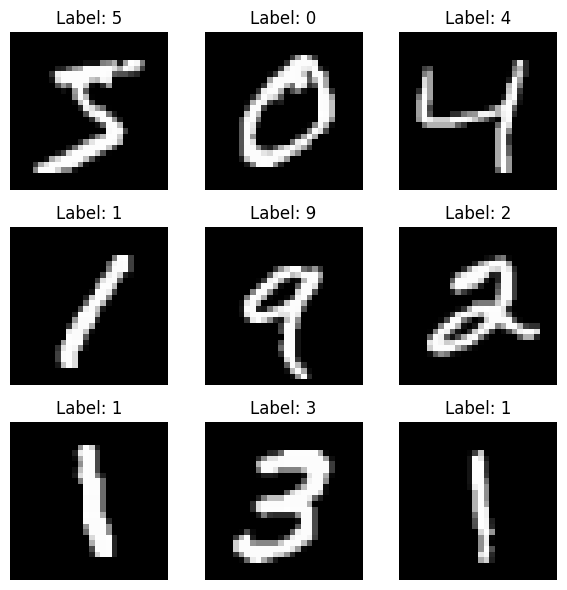

In [6]:
# Visualize the first 9 digits
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # to reduce overfitting
    Dense(10, activation='softmax')  # 10 output classes for digits 0–9
])

# Model summary
model


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>

In [8]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [9]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
422/422 - 27s - 65ms/step - accuracy: 0.9011 - loss: 0.3218 - val_accuracy: 0.9805 - val_loss: 0.0676
Epoch 2/5
422/422 - 40s - 94ms/step - accuracy: 0.9684 - loss: 0.1058 - val_accuracy: 0.9868 - val_loss: 0.0473
Epoch 3/5
422/422 - 42s - 100ms/step - accuracy: 0.9765 - loss: 0.0776 - val_accuracy: 0.9898 - val_loss: 0.0373
Epoch 4/5
422/422 - 40s - 94ms/step - accuracy: 0.9811 - loss: 0.0613 - val_accuracy: 0.9895 - val_loss: 0.0368
Epoch 5/5
422/422 - 41s - 97ms/step - accuracy: 0.9842 - loss: 0.0520 - val_accuracy: 0.9902 - val_loss: 0.0335


In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9903 - loss: 0.0278
Test Loss : 0.0278
Test Accuracy : 0.9903


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# predict the class
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("Classification report :\n",classification_report(y_true, y_pred_class))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Classification report :
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



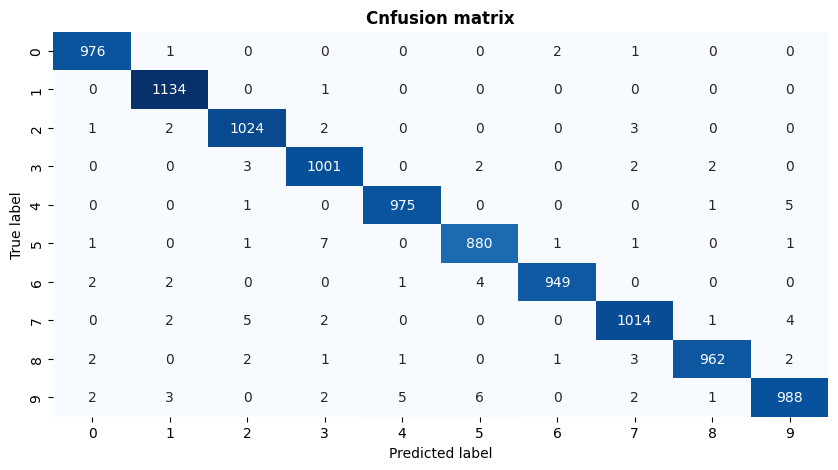

In [19]:
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(10,5))
sns.heatmap(data=cm, cmap='Blues',fmt='d',annot=True, cbar=False)
plt.title("Cnfusion matrix",fontweight='bold')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [20]:
prediction = model.predict(x_test)

predicted_class = np.argmax(prediction,axis=1)
true_class = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


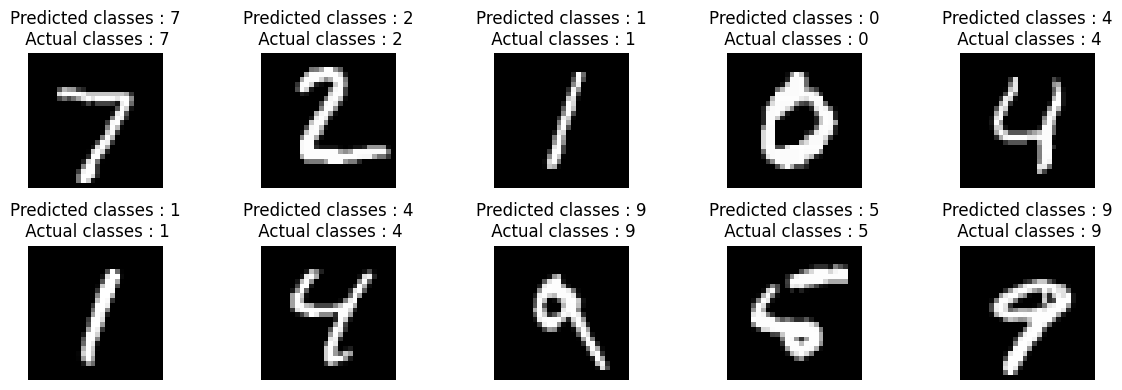

In [24]:
plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='grey')
    plt.title(f"Predicted classes : {predicted_class[i]}\n Actual classes : {true_class[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


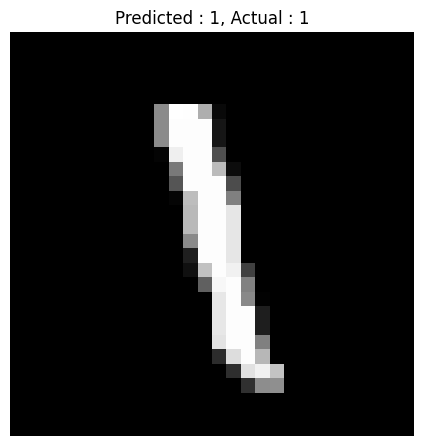

In [31]:
# Single image
index = 700
single_img = x_test[index].reshape(1, 28, 28, 1)

predicted_label = np.argmax(model.predict(single_img))
actual_label = np.argmax(y_test[index])

plt.imshow(x_test[index].reshape(28, 28), cmap='grey')
plt.title(f"Predicted : {predicted_label}, Actual : {actual_label}")
plt.tight_layout()
plt.axis('off')
plt.show()